# Scraping data Google Play Store

## Setup

In [1]:
!pip install google-play-scraper pandas numpy tqdm -q

In [2]:
from google_play_scraper import Sort, reviews
import pandas as pd
import time, os
from tqdm import tqdm
print("Libraries berhasil diimport")
print(f"Pandas version : {pd.__version__}")

Libraries berhasil diimport
Pandas version : 2.2.2


In [3]:
APPS = {
    'Tokopedia' : 'com.tokopedia.tkpd',
    'Shopee'    : 'com.shopee.id',
    'Bukalapak' : 'com.bukalapak.android'
}

TARGET_PER_APP = 4000
LANG    = 'id'
COUNTRY = 'id'

print(f"Target total data : {len(APPS) * TARGET_PER_APP:,} ulasan")
print(f"Aplikasi scraping : {list(APPS.keys())}")

Target total data : 12,000 ulasan
Aplikasi scraping : ['Tokopedia', 'Shopee', 'Bukalapak']


## Scraping

In [4]:
def scrape_app_reviews(app_id, app_name, target_count=2000):
    collected = []
    token = None
    pbar = tqdm(total=target_count, desc=f"  {app_name}", unit="ulasan")
    while len(collected) < target_count:
        batch = min(200, target_count - len(collected))
        try:
            result, token = reviews(
                app_id,
                lang=LANG, country=COUNTRY,
                sort=Sort.NEWEST,
                count=batch,
                continuation_token=token
            )
            if not result:
                break
            collected.extend(result)
            pbar.update(len(result))
            time.sleep(0.5)
            if token is None:
                break
        except Exception as e:
            print(f"\n Error pada {app_name}: {e}")
            time.sleep(2)
            break

    pbar.close()
    records = []
    for r in collected[:target_count]:
        records.append({
            'app_name'   : app_name,
            'app_id'     : app_id,
            'review_id'  : r.get('reviewId', ''),
            'username'   : r.get('userName', ''),
            'content'    : r.get('content', ''),
            'score'      : r.get('score', 0),
            'thumbs_up'  : r.get('thumbsUpCount', 0),
            'date'       : str(r.get('at', ''))
        })
    return records
print("Fungsi scraping siap digunakan")

Fungsi scraping siap digunakan


In [5]:
all_records = []

for app_name, app_id in APPS.items():
    print(f"Scraping {app_name} ({app_id})")
    records = scrape_app_reviews(app_id, app_name, TARGET_PER_APP)
    all_records.extend(records)
    print(f"Terkumpul {len(records):,} ulasan dari {app_name}")
    print(f"Total sejauh ini: {len(all_records):,} ulasan")
    time.sleep(1)
print(f"Scraping selesai! Total: {len(all_records):,} ulasan")

Scraping Tokopedia (com.tokopedia.tkpd)


  Tokopedia:   0%|          | 0/4000 [00:00<?, ?ulasan/s]

  Tokopedia: 100%|██████████| 4000/4000 [00:16<00:00, 235.86ulasan/s]


Terkumpul 4,000 ulasan dari Tokopedia
Total sejauh ini: 4,000 ulasan
Scraping Shopee (com.shopee.id)


  Shopee: 100%|██████████| 4000/4000 [00:17<00:00, 227.14ulasan/s]


Terkumpul 4,000 ulasan dari Shopee
Total sejauh ini: 8,000 ulasan
Scraping Bukalapak (com.bukalapak.android)


  Bukalapak: 100%|██████████| 4000/4000 [00:16<00:00, 244.10ulasan/s]


Terkumpul 4,000 ulasan dari Bukalapak
Total sejauh ini: 12,000 ulasan
Scraping selesai! Total: 12,000 ulasan


## Simpan Data

In [6]:
df_raw = pd.DataFrame(all_records)
df_raw = df_raw.drop_duplicates(subset=['review_id']).reset_index(drop=True)
df_raw = df_raw[df_raw['content'].str.strip().str.len() > 5].reset_index(drop=True)
os.makedirs('data', exist_ok=True)
df_raw.to_csv('data/raw_reviews.csv', index=False, encoding='utf-8-sig')
print(f"Statistik Dataset Raw:")
print(f"Total ulasan   : {len(df_raw):,}")
print(f"Kolom          : {list(df_raw.columns)}")
print(f"\nDistribusi Rating:")
print(df_raw['score'].value_counts().sort_index())
print(f"\nDistribusi per App:")
print(df_raw['app_name'].value_counts())
print(f"\nData tersimpan di: data/raw_reviews.csv")
df_raw.head()

Statistik Dataset Raw:
Total ulasan   : 10,831
Kolom          : ['app_name', 'app_id', 'review_id', 'username', 'content', 'score', 'thumbs_up', 'date']

Distribusi Rating:
score
1    4545
2     576
3     520
4     454
5    4736
Name: count, dtype: int64

Distribusi per App:
app_name
Bukalapak    3708
Tokopedia    3605
Shopee       3518
Name: count, dtype: int64

Data tersimpan di: data/raw_reviews.csv


,app_name,app_id,review_id,username,content,score,thumbs_up,date
0,Tokopedia,com.tokopedia.tkpd,c3402469-db7d-452b-8c6c-09336cf5ab9f,edelweis land,"kebanyak iklan anjir , mengganggu",1,0,2026-05-27 07:31:11
1,Tokopedia,com.tokopedia.tkpd,d77a4155-1a8b-4f3e-beb8-768173c41410,Tuwaga Pat,ati2bagi pengguna baru.apk scam.brg batal otom...,1,0,2026-05-27 07:30:40
2,Tokopedia,com.tokopedia.tkpd,bb889c2d-9d7c-4b2d-8300-67076fe0d1d0,M.Saiful Muzil,bagus sekali,5,0,2026-05-27 07:10:17
3,Tokopedia,com.tokopedia.tkpd,9d4c053b-b5a7-4923-8db8-333fba3b9f60,Ovalia Sugito,"Harga barang tertera 77rb, kq setelah mau di b...",1,0,2026-05-27 05:32:44
4,Tokopedia,com.tokopedia.tkpd,ebbfba4d-7e92-4bc8-b4b8-56b6211b63e4,Mulday Mulyadi,membantu belanja,5,0,2026-05-27 00:57:20


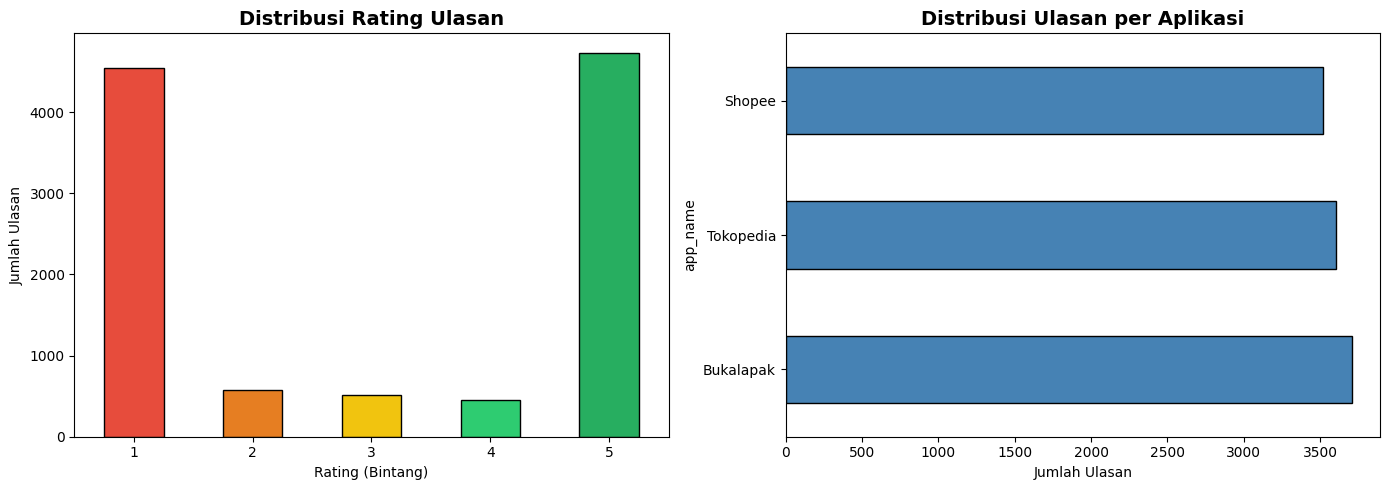

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi rating
df_raw['score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
    edgecolor='black'
)
axes[0].set_title('Distribusi Rating Ulasan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (Bintang)')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].tick_params(rotation=0)

# Distribusi per app
df_raw['app_name'].value_counts().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Distribusi Ulasan per Aplikasi', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()